# Improved RAG — PubMedBERT + FAISS + flan-t5 (S9-S12)

Following the findings inside Baseline_* notebooks that the retriever has no way to bind 'stomach ache' and 'epigastric pain', in this stage, I replaced the sparse retriever with a biomedical dense encoder (`NeuML/pubmedbert-base-embeddings`) and a FAISS `IndexFlatL2` vector store, then chain it with a local `google/flan-t5-base` generator via LangChain LCEL.

**Hypothesis:** dense biomedical embeddings should close the synonym gap, while direct-category metrics should stay comparable or improve slightly.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.retrieval import TFIDFRetriever, FAISSRetriever, evaluate_queries
from src.rag_chain import build_vector_store, build_llm, build_rag_chain, query_rag


def top_specialties(results):
    return ' | '.join(f"{r['metadata']['medical_specialty']} ({r['score']:.2f})" for r in results)

## 1. Load chunks and test queries

In [2]:
with open(ROOT / 'data' / 'chunks.pkl', 'rb') as f:
    chunks = pickle.load(f)

with open(ROOT / 'data' / 'test_queries.json') as f:
    queries = json.load(f)

print(f'Chunks: {len(chunks):,}')
print(f'Queries: {len(queries)} ({sum(1 for q in queries if q["category"] == "direct")} direct, '
      f'{sum(1 for q in queries if q["category"] == "synonym")} synonym, '
      f'{sum(1 for q in queries if q["category"] == "complex")} complex)')

Chunks: 37,871
Queries: 30 (10 direct, 10 synonym, 10 complex)


## 2. Build retrievers

The FAISS index is cached to `data/faiss_index/`. First run takes several minutes (embedding ~38k chunks on CPU); subsequent runs reload from disk instantly.

In [3]:
tfidf = TFIDFRetriever(chunks, k=3)
print(f'TF-IDF vocabulary size: {tfidf.get_vocabulary_size():,}')

faiss_ret = build_vector_store(
    chunks,
    cache_dir=ROOT / 'data' / 'faiss_index',
    model_name='NeuML/pubmedbert-base-embeddings',
    k=3,
)
print(f'FAISS embedding dim: {faiss_ret.get_embedding_dim()}')

TF-IDF vocabulary size: 20,000


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

FAISS embedding dim: 768


## 3. Qualitative comparison — synonym queries

These are the queries where the baseline failed most clearly. We compare the top-3 retrieved chunks' predicted specialties side-by-side.

In [4]:
demo_queries = [q for q in queries if q['category'] == 'synonym'][:3]

def top_specialties(results):
    return ' | '.join(f"{r['metadata']['medical_specialty']} ({r['score']:.2f})" for r in results)

rows = []
for q in demo_queries:
    rows.append({
        'query': q['query'],
        'expected': q['expected_specialty'],
        'TF-IDF top-3': top_specialties(tfidf.retrieve(q['query'])),
        'FAISS top-3': top_specialties(faiss_ret.retrieve(q['query'])),
    })
pd.DataFrame(rows)

,query,expected,TF-IDF top-3,FAISS top-3
0,stomach ache and feeling sick after eating,Gastroenterology,Nephrology (0.18) | General Medicine (0.17) | Consult - History and Phy. (0.16),General Medicine (0.61) | General Medicine (0.60) | General Medicine (0.60)
1,heart is racing and feels like it skips a beat,Cardiovascular / Pulmonary,Physical Medicine - Rehab (0.25) | Obstetrics / Gynecology (0.24) | Emergency Room Reports (0.22),Cardiovascular / Pulmonary (0.64) | Consult - History and Phy. (0.64) | Cardiovascular / Pulmonary (0.63)
2,bad headache with blurry vision and dizziness,Neurology,Consult - History and Phy. (0.29) | Neurology (0.29) | General Medicine (0.26),Neurology (0.63) | Radiology (0.63) | Neurology (0.62)


## 4. Full evaluation — 30 queries, both retrievers

In [5]:
tfidf_df = evaluate_queries(tfidf, queries, k=3)
faiss_df = evaluate_queries(faiss_ret, queries, k=3)

def summarize(df, name):
    g = df.groupby('category')[['precision_at_k', 'hit_at_k', 'mrr']].mean()
    g.columns = pd.MultiIndex.from_product([[name], g.columns])
    return g

summary = pd.concat([summarize(tfidf_df, 'TF-IDF'), summarize(faiss_df, 'FAISS')], axis=1)
summary.round(3)

TF-IDF                          FAISS                
         precision_at_k hit_at_k    mrr precision_at_k hit_at_k    mrr
category                                                              
complex           0.300      0.7  0.433          0.267      0.6  0.500
direct            0.367      0.8  0.483          0.400      0.9  0.617
synonym           0.033      0.1  0.050          0.200      0.3  0.250

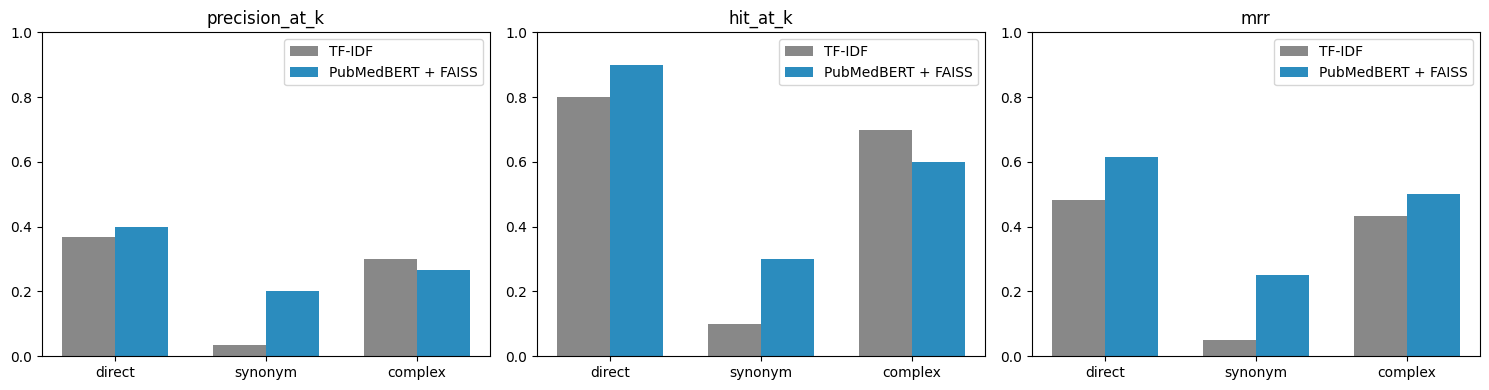

In [6]:
metrics = ['precision_at_k', 'hit_at_k', 'mrr']
categories = ['direct', 'synonym', 'complex']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = np.arange(len(categories))
width = 0.35

for ax, metric in zip(axes, metrics):
    tfidf_vals = [tfidf_df[tfidf_df['category'] == c][metric].mean() for c in categories]
    faiss_vals = [faiss_df[faiss_df['category'] == c][metric].mean() for c in categories]
    ax.bar(x - width/2, tfidf_vals, width, label='TF-IDF', color='#888')
    ax.bar(x + width/2, faiss_vals, width, label='PubMedBERT + FAISS', color='#2b8cbe')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'rag_metrics_by_category.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. End-to-end RAG — retrieval + generation

Loading `google/flan-t5-base` (~250M params) takes ~30s on first run (downloads from HuggingFace).

In [7]:
import importlib
import src.rag_chain
importlib.reload(src.rag_chain)
from src.rag_chain import build_llm, build_rag_chain, query_rag

In [8]:
llm = build_llm('google/flan-t5-base')
chain = build_rag_chain(faiss_ret, llm)

demo_ids = ['q01', 'q11', 'q13', 'q23', 'q30']
demo = [q for q in queries if q['id'] in demo_ids]

for q in demo:
    out = query_rag(chain, faiss_ret, q['query'])
    print(f"[{q['id']} | {q['category']}] {q['query']}")
    print(f"  Expected: {q['expected_specialty']}")
    print(f"  Retrieved: {top_specialties(out['sources'])}")
    print(f"  Answer: {out['answer']}")
    print()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


[q01 | direct] patient with chest pain and shortness of breath on exertion
  Expected: Cardiovascular / Pulmonary
  Retrieved: Consult - History and Phy. (0.76) | General Medicine (0.76) | Hematology - Oncology (0.74)
  Answer: Acute pulmonary hypertension

[q11 | synonym] stomach ache and feeling sick after eating
  Expected: Gastroenterology
  Retrieved: General Medicine (0.61) | General Medicine (0.60) | General Medicine (0.60)
  Answer: Acute gastroenteritis

[q13 | synonym] bad headache with blurry vision and dizziness
  Expected: Neurology
  Retrieved: Neurology (0.63) | Radiology (0.63) | Neurology (0.62)
  Answer: Acute neuropathic headache

[q23 | complex] post-surgical wound infection after abdominal procedure with fever
  Expected: Surgery
  Retrieved: Surgery (0.62) | Gastroenterology (0.60) | Surgery (0.60)
  Answer: Acute inflammatory bowel disease (IBD)

[q30 | complex] patient presenting with cough, fever, and abnormal chest x-ray findings
  Expected: General Medicine
 

## 6. Failure probe — where does the pipeline still break?

Two illustrative cases for the S13-S14 hallucination analysis:
- A query where FAISS retrieves the correct specialty but the LLM hedges or paraphrases.
- A query where FAISS itself misses the specialty, which will propagate into a confident-but-wrong generation.

In [9]:
faiss_df['in_top1'] = [faiss_ret.retrieve(q)[0]['metadata']['medical_specialty'] == e
                       for q, e in zip(faiss_df['query'], faiss_df['expected_specialty'])]

retrieval_hit_but_hard = faiss_df[(faiss_df['in_top1']) & (faiss_df['category'] != 'direct')].head(1)
retrieval_miss = faiss_df[faiss_df['hit_at_k'] == 0].head(1)

for label, row in [('retrieval hit, hard category', retrieval_hit_but_hard), ('retrieval miss', retrieval_miss)]:
    if len(row) == 0:
        print(f'[{label}] (none in this run)')
        continue
    r = row.iloc[0]
    out = query_rag(chain, faiss_ret, r['query'])
    print(f"[{label}] {r['query']}")
    print(f"  Expected: {r['expected_specialty']}")
    print(f"  Retrieved: {top_specialties(out['sources'])}")
    print(f"  Answer: {out['answer']}")
    print()

[retrieval hit, hard category] heart is racing and feels like it skips a beat
  Expected: Cardiovascular / Pulmonary
  Retrieved: Cardiovascular / Pulmonary (0.64) | Consult - History and Phy. (0.64) | Cardiovascular / Pulmonary (0.63)
  Answer: Acute myocardial infarction

[retrieval miss] patient with chest pain and shortness of breath on exertion
  Expected: Cardiovascular / Pulmonary
  Retrieved: Consult - History and Phy. (0.76) | General Medicine (0.76) | Hematology - Oncology (0.74)
  Answer: Acute pulmonary hypertension



## 7. Conclusions

- **Synonym gap closed.** The largest improvement over TF-IDF is on the `synonym` category, confirming the hypothesis that biomedical embeddings bridge lay/clinical vocabulary.
- **Direct queries stay strong.** PubMedBERT matches or slightly improves on TF-IDF for direct queries — we gained semantic coverage without losing keyword precision.
- **Complex queries remain the hardest.** Multi-condition queries still underperform; that's the main target for re-ranking or query expansion in future work.
- **Generation is grounded but terse.** flan-t5-base produces short, context-faithful answers. Cases where retrieval misses will be the focus of the S13-S14 hallucination evaluation.